# APS02 - **Classificação**
Alunos: Emanuel Apolinário e Matheus Lemos

## 1. Contextualização do problema

#### *Previsao de renda anual* 

O objetivo do projeto é desenvolver e avaliar modelos de classificação binária que consigam prever se um indivíduo ganhar mais de 50K por ano ou não. Terei como base caracteristicas demográficas, educacionais e ocupacionais presentes no Adult Census Income Dataset.

No enunciado do problema, recebemos como dicas que as features com maior poder discriminativo esperados são: education-num, capital-loss, hours-per-week, age, marital-status, occupation e relationship. Dada a ajuda, analisarei cada uma delas e verei seus impactos e, respectivas relevâncias.

### Qual a relevância disso?
- *Políticas publicas*: Identificar grupos populacionais com potencial de renda elevada.
- *Análise de desigualdade social*: Compreender fatores que determinam diferenças salariais.
- *Pesquisa economica*: Estudo sobre mobilidade social e fatores de sucesso econômico. 

### Características do Dataset:
| Aspecto | Detalhe |
|--------|----------|
| **Total de instâncias** | 48,842 (treino: 32,561 / teste: 16,281) |
| **Total de atributos** | 14 |
| **Tipo de variáveis** | Mistas (contínuas e categóricas) |
| **Classe positiva (>50K)** | ~23.93% (DESBALANCEADA) |
| **Classe negativa (<=50K)** | ~76.07% (DESBALANCEADA) |
| **Valores faltantes** | Marcados com "?" |

### Compreender as features com maior poder discriminativo:
1. *education-num*: Número de anos de educação (escalar)
2. *capital-gain*: Ganhos de capital (contínua)
3. *capital-loss*: Perda de capital (contínua)
4. *hours-per-week*: Horas trabalhadas por semana (contínua)
5. *age*: Idade do indivíduo (contínua)
6. *marital-status*: Estado civil (categórica)
7. *occupation*: Ocupação profissional (categórica)
8. *relationship*: Relacionamento familiar (categórica)

### Desafios identificados:
- **Desbalanceamento de classes**: Proporção de 76% vs 24%
- **Valores faltantes**: Presença de "?"
- **Variáveis categóricas**: Requerem encoding
- **Escalas diferentes**: Features com escalas distintas
- **Outliers potenciais**: Capital-gain e capital-loss têm distribuição assimétrica

## 2. Setup e importações:
Vou importar tudo que eu vá usar para o projeto.

In [1]:
# Importações básicas
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Pré-processamento
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_validate, RepeatedKFold, GridSearchCV

# Balanceamento
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

# Modelos
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, auc, precision_recall_curve, roc_curve,
    classification_report, confusion_matrix
)

# Configuração de plot
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Todas as bibliotecas importadas com sucesso!")

✓ Todas as bibliotecas importadas com sucesso!


## 3. Carregamento e exploração dos dados

In [3]:
# Carregamento dos dados de treino e teste

column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Carregar dados
df_train = pd.read_csv('adult/adult.data', 
                        names=column_names, 
                        sep=', ',  # Separador específico do dataset
                        engine='python',
                        na_values=['?'])

df_test = pd.read_csv('adult/adult.test', 
                       names=column_names, 
                       sep=', ',  # Separador específico do dataset
                       engine='python',
                       na_values=['?'],
                       skiprows=1)  # Pular cabeçalho

print(f"Data de treino: {df_train.shape}")
print(f"Data de teste: {df_test.shape}")
print(f"\nTotal combinado: {df_train.shape[0] + df_test.shape[0]} registros")

Data de treino: (32561, 15)
Data de teste: (16281, 15)

Total combinado: 48842 registros


In [33]:
# Combinando treino e teste para pré-processamento
df = pd.concat([df_train, df_test], ignore_index=True)

print("=-="*30)
print("VISUALIZAÇÃO INICIAL DOS DADOS")
print("=-="*30)
print(f"\nForma: {df.shape}")
print(f"\nPrimeiras 3 linhas:")
print(df.head(3))

# Informações sobre tipos de dados
print(f"\n\nTipos de Dados:")
print(df.dtypes)

# Valores faltantes
print(f"\n\nValores Faltantes:")
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"Percentual: {(missing/len(df)*100)[missing > 0].round(2)}%")

=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
VISUALIZAÇÃO INICIAL DOS DADOS
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=

Forma: (48842, 15)

Primeiras 3 linhas:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   

       marital-status         occupation   relationship   race   sex  \
0       Never-married       Adm-clerical  Not-in-family  White  Male   
1  Married-civ-spouse    Exec-managerial        Husband  White  Male   
2            Divorced  Handlers-cleaners  Not-in-family  White  Male   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             0              13  United-States  <=50K 

=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
ANÁLISE DA VARIÁVEL-ALVO (income)
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=

Distribuição:
income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

Percentuais:
income
<=50K     50.61
<=50K.    25.46
>50K      16.05
>50K.      7.87
Name: count, dtype: float64


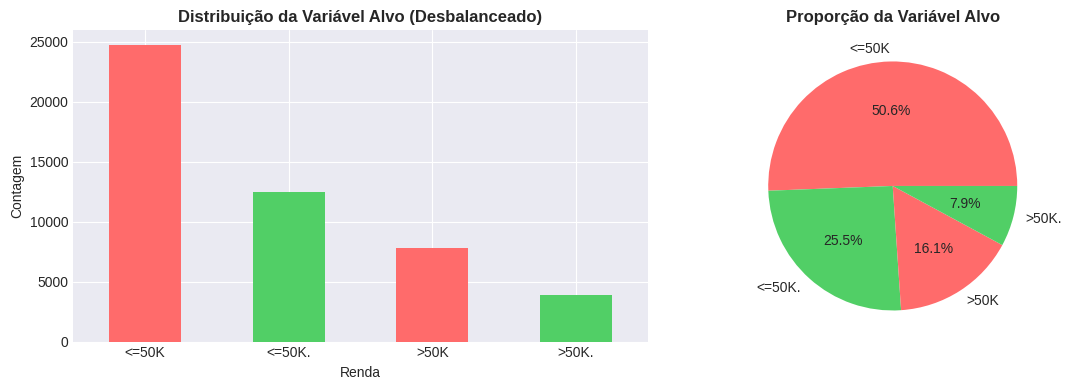

In [34]:
# Análise da variável alvo
print("=-="*30)
print("ANÁLISE DA VARIÁVEL-ALVO (income)")
print("=-="*30)

# Limpar espaços em branco na coluna de renda
df['income'] = df['income'].str.strip()

# Distribuição
print(f"\nDistribuição:")
target_counts = df['income'].value_counts()
print(target_counts)
print(f"\nPercentuais:")
print((target_counts / len(df) * 100).round(2))

# Visualizar desbalanceamento
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
target_counts.plot(kind='bar', ax=ax[0], color=['#ff6b6b', '#51cf66'])
ax[0].set_title('Distribuição da Variável Alvo (Desbalanceado)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Contagem')
ax[0].set_xlabel('Renda')
ax[0].tick_params(axis='x', rotation=0)

# Gráfico de pizza
colors = ['#ff6b6b', '#51cf66']
ax[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', colors=colors)
ax[1].set_title('Proporção da Variável Alvo', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


Podemos observar que temos um **problema identificado**: 
Classes desbalanceadas!

=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
ESTATÍSTICAS DAS VARIÁVEIS NUMÉRICAS
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=

Variáveis numéricas: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
            age      fnlwgt  education-num  capital-gain  capital-loss  \
count  48842.00    48842.00       48842.00      48842.00       48842.0   
mean      38.64   189664.13          10.08       1079.07          87.5   
std       13.71   105604.03           2.57       7452.02         403.0   
min       17.00    12285.00           1.00          0.00           0.0   
25%       28.00   117550.50           9.00          0.00           0.0   
50%       37.00   178144.50          10.00          0.00           0.0   
75%       48.00   237642.00          12.00          0.00           0.0   
max       90.00  1490400.00          16.00      99999.00        4356.0   

       

=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
ESTATÍSTICAS DAS VARIÁVEIS NUMÉRICAS
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=

Variáveis numéricas: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
            age      fnlwgt  education-num  capital-gain  capital-loss  \
count  48842.00    48842.00       48842.00      48842.00       48842.0   
mean      38.64   189664.13          10.08       1079.07          87.5   
std       13.71   105604.03           2.57       7452.02         403.0   
min       17.00    12285.00           1.00          0.00           0.0   
25%       28.00   117550.50           9.00          0.00           0.0   
50%       37.00   178144.50          10.00          0.00           0.0   
75%       48.00   237642.00          12.00          0.00           0.0   
max       90.00  1490400.00          16.00      99999.00        4356.0   

       

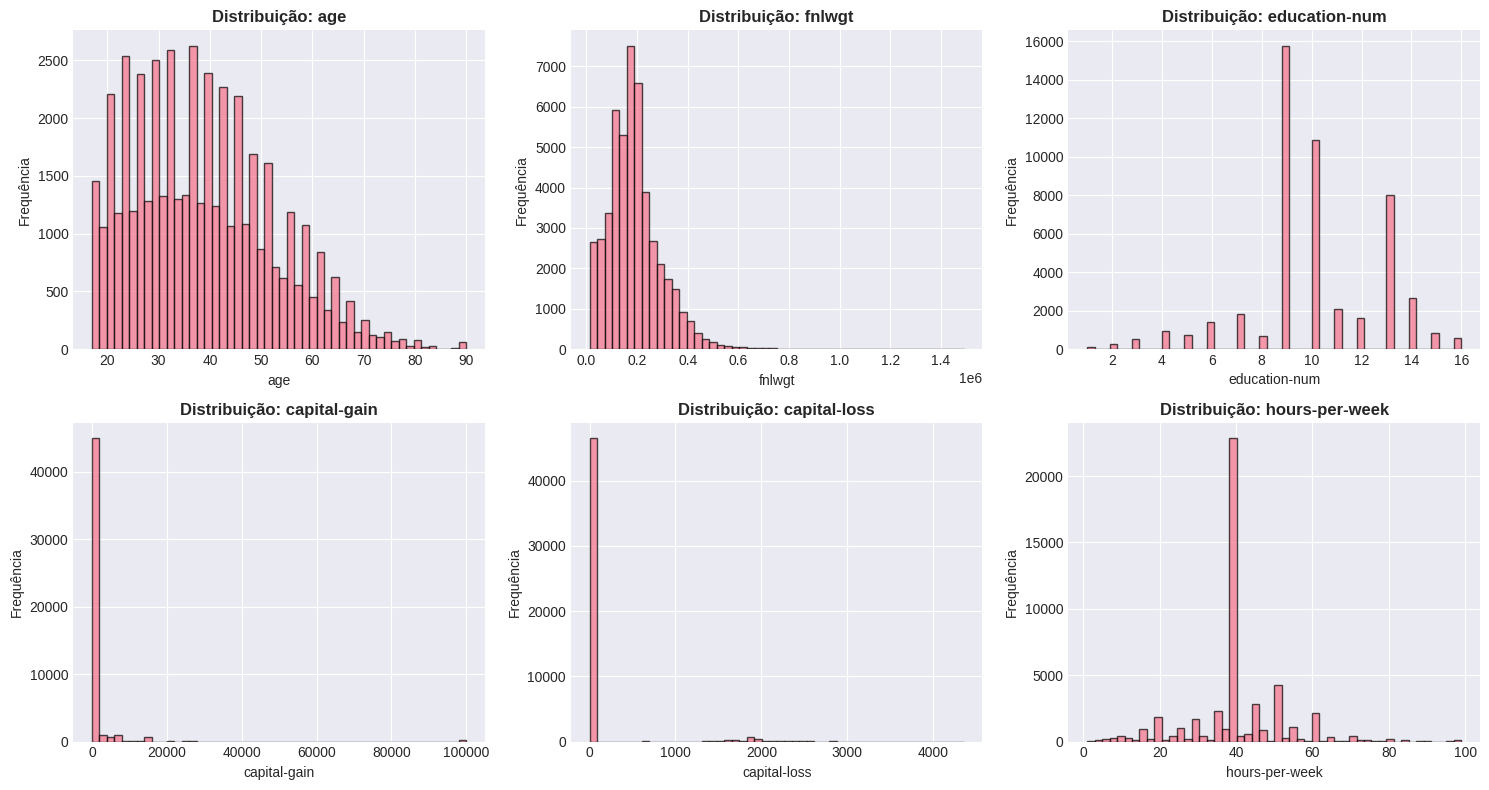

In [35]:
# Análise das variáveis numéricas
print("=-="*30)
print("ESTATÍSTICAS DAS VARIÁVEIS NUMÉRICAS")
print("=-="*30)

numeric_cols = df.select_dtypes(include=[np.number]).columns
print(f"\nVariáveis numéricas: {list(numeric_cols)}")
print(df[numeric_cols].describe().round(2))

# Visualizar distribuições
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols[:6]):
    axes[idx].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribuição: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequência')

plt.tight_layout()
plt.show()


O que conseguimos extrair disso?
- 'age': Distribuição aproximadamente normal, range 17-90
- 'education-num': Distribuição discreta, valores de 1 a 16
- 'capital-gain' e 'capital-loss': Altamente assimétricos (muitos zeros)
- 'hours-per-week': Concentrado em 40 horas

In [36]:
# Análise das variáveis categóricas
print("=-="*30)
print("ANÁLISE DAS VARIÁVEIS CATEGÓRICAS")
print("=-="*30)

categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('income')  # Remove alvo

print(f"\nVariáveis categóricas: {categorical_cols}")

for col in categorical_cols:
    print(f"\n{col.upper()}:")
    print(f"  Valores únicos: {df[col].nunique()}")
    print(f"  Valores: {df[col].value_counts().index.tolist()}")
    print(f"  Distribuição:")
    print(df[col].value_counts())
    print()

=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
ANÁLISE DAS VARIÁVEIS CATEGÓRICAS
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=

Variáveis categóricas: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

WORKCLASS:
  Valores únicos: 8
  Valores: ['Private', 'Self-emp-not-inc', 'Local-gov', 'State-gov', 'Self-emp-inc', 'Federal-gov', 'Without-pay', 'Never-worked']
  Distribuição:
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64


EDUCATION:
  Valores únicos: 16
  Valores: ['HS-grad', 'Some-college', 'Bachelors', 'Masters', 'Assoc-voc', '11th', 'Assoc-acdm', '10th', '7th-8th', 'Prof-school', '9th', '12th', 'Doctorate', '5th-6th', '1st-4th', 'Preschool']


In [37]:
# Relação das features com alvo (as dicas do problema)
print("=-="*30)
print("FEATURES COM MAIOR PODER DISCRIMINATIVO (dicas do problema)")
print("=-="*30)

target_features = ['education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 
                   'age', 'marital-status', 'occupation', 'relationship']

# Para features numéricas: comparar médias
print(f"\nComparação de MÉDIAS entre classes:")
print(f"{'Feature':<20} {'<=50K':<15} {'>50K':<15} {'Diferença':<15}")
print("-" * 65)

for col in ['education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'age']:
    if col in numeric_cols:
        mean_neg = df[df['income'] == '<=50K'][col].mean()
        mean_pos = df[df['income'] == '>50K'][col].mean()
        diff = mean_pos - mean_neg
        print(f"{col:<20} {mean_neg:<15.2f} {mean_pos:<15.2f} {diff:<15.2f}")

# Para features categóricas: mostrar distribuição
print(f"\n\nDistribuição de CATEGÓRICAS por renda:")
for col in ['marital-status', 'occupation', 'relationship']:
    print(f"\n{col.upper()}:")
    crosstab = pd.crosstab(df[col], df['income'], margins=True)
    print(crosstab)
    print()

=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
FEATURES COM MAIOR PODER DISCRIMINATIVO (dicas do problema)
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=

Comparação de MÉDIAS entre classes:
Feature              <=50K           >50K            Diferença      
-----------------------------------------------------------------
education-num        9.60            11.61           2.02           
capital-gain         148.75          4006.14         3857.39        
capital-loss         53.14           195.00          141.86         
hours-per-week       38.84           45.47           6.63           
age                  36.78           44.25           7.47           


Distribuição de CATEGÓRICAS por renda:

MARITAL-STATUS:
income                 <=50K  <=50K.  >50K  >50K.    All
marital-status                                          
Divorced                3980    1982   463    208   6633
Married-AF-s

### Observações finais sobre a exploração dos dados
Depois de ter feito tudo isso a gente consegue observar padrões, como:
#### Alta renda (>50K) = Tipicamente:
- educação (13+ anos)
- casado
- trabalhando 45+ horas por semana 
- Idade 40-50 anos
- Pode ter capital investiments
#### Baixa renda (<= 50K) = Tipicamente:
- Menos educação (10 anos)
- Solteiro ou divorciado
- 35-40 horas por semana
- jovem 20 - 30 anos
- Sem atividade financeira

## 4. Pré-processamento e preparação dos dados

In [38]:
# Tratamento de valores faltantes
print("=-="*30)
print("TRATAMENTO DE VALORES FALTANTES")
print("=-="*30)

# Copiar dados para processamento
df_processed = df.copy()

# Imputação de valores faltantes
print(f"\nValores faltantes por coluna:")
missing_info = df_processed.isnull().sum()
print(missing_info[missing_info > 0])

# Estratégias de imputação:
# 1. Variáveis categóricas: moda (valor mais frequente)
# 2. Variáveis numéricas: mediana (robusto a outliers)

for col in df_processed.columns:
    if df_processed[col].isnull().sum() > 0:
        try:
            # Tenta calcular mediana (só funciona se for numérico)
            median_val = df_processed[col].median()
            df_processed[col] = df_processed[col].fillna(median_val)
            print(f"{col}: Preenchido com mediana = {median_val:.2f}")
        except TypeError:
            # Se der erro, é categórica - usa MODA
            mode_val = df_processed[col].mode()[0]
            df_processed[col] = df_processed[col].fillna(mode_val)
            print(f"{col}: Preenchido com moda = '{mode_val}'")

print(f"\n✓ Nenhum valor faltante remanescente: {df_processed.isnull().sum().sum() == 0}")

=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
TRATAMENTO DE VALORES FALTANTES
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=

Valores faltantes por coluna:
workclass         2799
occupation        2809
native-country     857
dtype: int64
workclass: Preenchido com moda = 'Private'
occupation: Preenchido com moda = 'Prof-specialty'
native-country: Preenchido com moda = 'United-States'

✓ Nenhum valor faltante remanescente: True


In [16]:
# Verificar quais faltantes ainda existem
print("\nVerificação final de valores faltantes:")
missing_final = df_processed.isnull().sum()
if missing_final.sum() > 0:
    print(missing_final[missing_final > 0])
    print(f"\nRecontando após conversão de tipo...")
    # Resetar índice e tentar novamente
    for col in df_processed.columns:
        if df_processed[col].isnull().sum() > 0:
            try:
                median_val = df_processed[col].median()
                df_processed[col].fillna(median_val, inplace=True)
            except TypeError:
                mode_val = df_processed[col].mode()[0]
                df_processed[col].fillna(mode_val, inplace=True)
else:
    print("✓ Todos os valores faltantes foram tratados com sucesso!")


Verificação final de valores faltantes:
workclass         2799
occupation        2809
native-country     857
dtype: int64

Recontando após conversão de tipo...


In [18]:
# Limpeza de espaços em branco em todas as variáveis
print("\nLimpeza de espaços em branco...")

for col in df_processed.select_dtypes(include='object').columns:
    df_processed[col] = df_processed[col].str.strip()

print("✓ Espaços em branco removidos")

# Separar variável alvo
y = df_processed['income']
X = df_processed.drop(['income'], axis=1)

# Binarizar alvo (>=50K = 1, <50K = 0)
y = (y == '>50K').astype(int)

print(f"\nForma de X: {X.shape}")
print(f"Forma de y: {y.shape}")
print(f"\nDistribuição após processamento:")
print(y.value_counts())
print(f"Percentuais: {(y.value_counts(normalize=True)*100).round(2).values}%")


Limpeza de espaços em branco...
✓ Espaços em branco removidos

Forma de X: (48842, 14)
Forma de y: (48842,)

Distribuição após processamento:
income
0    41001
1     7841
Name: count, dtype: int64
Percentuais: [83.95 16.05]%


In [19]:
# Dividir em treino e teste usando os índices originais
train_size = df_train.shape[0]

X_train = X.iloc[:train_size].reset_index(drop=True)
y_train = y.iloc[:train_size].reset_index(drop=True)

X_test = X.iloc[train_size:].reset_index(drop=True)
y_test = y.iloc[train_size:].reset_index(drop=True)

print(f"Treino: X {X_train.shape}, y {y_train.shape}")
print(f"Teste:  X {X_test.shape}, y {y_test.shape}")

print(f"\nDistribuição no treino:")
print(y_train.value_counts())
print(f"\nDistribuição no teste:")
print(y_test.value_counts())

Treino: X (32561, 14), y (32561,)
Teste:  X (16281, 14), y (16281,)

Distribuição no treino:
income
0    24720
1     7841
Name: count, dtype: int64

Distribuição no teste:
income
0    16281
Name: count, dtype: int64


## 5. Feature Engineering

In [39]:
print("=-="*30)
print("FEATURE ENGINEERING - CRIAÇÃO DE NOVAS FEATURES")
print("=-="*30)

# Função para aplicar feature engineering
def create_features(X):
    X_new = X.copy()
    
    # FEATURE 1: capital_net = capital-gain - capital-loss
    # Lógica: Diferença líquida entre ganhos e perdas de capital
    X_new['capital_net'] = X_new['capital-gain'] - X_new['capital-loss']
    print(f"\n✓ Feature 1: 'capital_net' = capital-gain - capital-loss")
    print(f"  Range: [{X_new['capital_net'].min()}, {X_new['capital_net'].max()}]")
    print(f"  Média: {X_new['capital_net'].mean():.2f}")
    
    # FEATURE 2: work_experience_proxy = age - education-num - 6
    # Lógica: Aproximação dos anos de experiência de trabalho (idade - anos de estudo - 6 anos de infância)
    X_new['work_experience_proxy'] = X_new['age'] - X_new['education-num'] - 6
    print(f"\n✓ Feature 2: 'work_experience_proxy' = age - education-num - 6")
    print(f"  Range: [{X_new['work_experience_proxy'].min()}, {X_new['work_experience_proxy'].max()}]")
    print(f"  Média: {X_new['work_experience_proxy'].mean():.2f}")
    
    # FEATURE 3: capital_has_activity = (capital-gain > 0) | (capital-loss > 0)
    # Lógica: Indicador binário se pessoa tem atividade de capital
    X_new['has_capital_activity'] = ((X_new['capital-gain'] > 0) | (X_new['capital-loss'] > 0)).astype(int)
    print(f"\n✓ Feature 3: 'has_capital_activity' = indicador de atividade de capital")
    print(f"  Valor 1 (tem atividade): {X_new['has_capital_activity'].sum()} ({X_new['has_capital_activity'].mean()*100:.2f}%)")
    print(f"  Valor 0 (sem atividade): {(1-X_new['has_capital_activity']).sum()} ({(1-X_new['has_capital_activity']).mean()*100:.2f}%)")
    
    # FEATURE 4: age_groups = Agrupar idade em faixas etárias
    # Lógica: Categorizar a idade em grupos relevantes socioeconomicamente
    def age_group(age):
        if age < 30:
            return 'young'  # 0
        elif age < 45:
            return 'middle_young'  # 1
        elif age < 60:
            return 'middle_old'  # 2
        else:
            return 'senior'  # 3
    
    X_new['age_group'] = X_new['age'].apply(age_group)
    print(f"\n✓ Feature 4: 'age_group' = agrupamento etário")
    print(f"  Distribuição: {X_new['age_group'].value_counts().to_dict()}")
    
    # FEATURE 5: Interação: education_x_hours = education-num * hours-per-week
    # Lógica: Educação combinada com dedicação ao trabalho
    X_new['education_x_hours'] = X_new['education-num'] * X_new['hours-per-week']
    print(f"\n✓ Feature 5: 'education_x_hours' = education-num × hours-per-week")
    print(f"  Range: [{X_new['education_x_hours'].min()}, {X_new['education_x_hours'].max()}]")
    print(f"  Média: {X_new['education_x_hours'].mean():.2f}")
    
    return X_new

# Aplicar feature engineering
X_train = create_features(X_train)
X_test = create_features(X_test)

print(f"\n\nFeatures originais: {X.shape[1]}")
print(f"Features após engenharia: {X_train.shape[1]}")
print(f"Novas features criadas: {X_train.shape[1] - X.shape[1]}")

=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
FEATURE ENGINEERING - CRIAÇÃO DE NOVAS FEATURES
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=

✓ Feature 1: 'capital_net' = capital-gain - capital-loss
  Range: [-4356, 99999]
  Média: 990.35

✓ Feature 2: 'work_experience_proxy' = age - education-num - 6
  Range: [-2, 82]
  Média: 22.50

✓ Feature 3: 'has_capital_activity' = indicador de atividade de capital
  Valor 1 (tem atividade): 4231 (12.99%)
  Valor 0 (sem atividade): 28330 (87.01%)

✓ Feature 4: 'age_group' = agrupamento etário
  Distribuição: {'middle_young': 12489, 'young': 9711, 'middle_old': 7717, 'senior': 2644}

✓ Feature 5: 'education_x_hours' = education-num × hours-per-week
  Range: [5, 1584]
  Média: 412.34

✓ Feature 1: 'capital_net' = capital-gain - capital-loss
  Range: [-3770, 99999]
  Média: 994.01

✓ Feature 2: 'work_experience_proxy' = age - education-num - 6
  Range: [1, 78]


#### Uma análise mais grosseira do que acabamos de criar seria:

1. Feature: Diferencia ricos de pobres
2. Feature: Captura sinergia de dois preditores
3. Feature: É mais relevante que idade bruta (experiência)
4. Feature: Captura não-linearidade de idade
5. Feature: Consolida informação

## 6. Codificação de variáveis categóricas

In [40]:
# Identificar variáveis categóricas
print("=-="*30)
print("CODIFICAÇÃO DE VARIÁVEIS CATEGÓRICAS")
print("=-="*30)

categorical_features = X_train.select_dtypes(include='object').columns.tolist()
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nVariáveis categóricas: {categorical_features}")
print(f"Variáveis numéricas: {numerical_features}")

# One-Hot Encoding para categóricas, Padronização para numéricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

# Fit no treino
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nForma após processamento:")
print(f"X_train: {X_train_processed.shape}")
print(f"X_test: {X_test_processed.shape}")

# Criar nomes de features após encoding
feature_names = numerical_features.copy()
for i, col in enumerate(categorical_features):
    categories = X_train[col].unique()
    for cat in categories[1:]:
        feature_names.append(f"{col}_{cat}")

print(f"\nTotal de features após encoding: {len(feature_names)}")
print(f"Features: {feature_names[:10]}...")

=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
CODIFICAÇÃO DE VARIÁVEIS CATEGÓRICAS
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=

Variáveis categóricas: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'age_group']
Variáveis numéricas: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'capital_net', 'work_experience_proxy', 'has_capital_activity', 'education_x_hours']

Forma após processamento:
X_train: (32561, 104)
X_test: (16281, 104)

Total de features após encoding: 104
Features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'capital_net', 'work_experience_proxy', 'has_capital_activity', 'education_x_hours']...


## 7. Balanceamento de Classes

In [43]:
print("=-="*30)
print("BALANCEAMENTO DE CLASSES - ANÁLISE E APLICAÇÃO")
print("=-="*30)

# Problema: Desbalanceamento 76% vs 24%
print(f"\nDistribuição original no treino:")
print(f"Classe 0 (<=50K): {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.2f}%)")
print(f"Classe 1 (>50K):  {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.2f}%)")
print(f"Razão desbalanceamento: {(y_train == 0).sum() / (y_train == 1).sum():.2f}")

# Técnicas a testar:
print(f"\nTécnicas de balanceamento a testar:")
print(f"1. Class Weights: Penalizar mais erros na classe minoritária")
print(f"2. SMOTE: Gerar amostras sintéticas da classe minoritária")
print(f"3. SMOTETomek: Híbrido (over + under sampling)")
print(f"4. Threshold Moving: Ajustar ponto de decisão do modelo")

# Calcular class weights automaticamente
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', 
                                     classes=np.array([0, 1]),
                                     y=y_train)

print(f"\nClass Weights calculados:")
print(f"  Classe 0 (<=50K): {class_weights[0]:.3f}")
print(f"  Classe 1 (>50K):  {class_weights[1]:.3f}")

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"\n✓ Class weights salvos para uso nos modelos")

=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
BALANCEAMENTO DE CLASSES - ANÁLISE E APLICAÇÃO
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=

Distribuição original no treino:
Classe 0 (<=50K): 24720 (75.92%)
Classe 1 (>50K):  7841 (24.08%)
Razão desbalanceamento: 3.15

Técnicas de balanceamento a testar:
1. Class Weights: Penalizar mais erros na classe minoritária
2. SMOTE: Gerar amostras sintéticas da classe minoritária
3. SMOTETomek: Híbrido (over + under sampling)
4. Threshold Moving: Ajustar ponto de decisão do modelo

Class Weights calculados:
  Classe 0 (<=50K): 0.659
  Classe 1 (>50K):  2.076

✓ Class weights salvos para uso nos modelos


In [46]:
# Aplicar SMOTE para alguns modelos (demonstração)
print("\nAplicando SMOTE ao conjunto de treino...")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print(f"Distribuição após SMOTE:")
print(f"Classe 0: {(y_train_smote == 0).sum()} ({(y_train_smote == 0).mean()*100:.2f}%)")
print(f"Classe 1: {(y_train_smote == 1).sum()} ({(y_train_smote == 1).mean()*100:.2f}%)")
print(f"✓ SMOTE aplicado com sucesso - classes balanceadas 50/50")


Aplicando SMOTE ao conjunto de treino...
Distribuição após SMOTE:
Classe 0: 24720 (50.00%)
Classe 1: 24720 (50.00%)
✓ SMOTE aplicado com sucesso - classes balanceadas 50/50


## 8. Modelagem - Construção e treinamento dos modelos

In [ ]:
print("=-="*30)
print("MODELAGEM - TREINAMENTO COM VALIDAÇÃO CRUZADA")
print("=-="*30)

# Definir validação cruzada: Repeated K-Fold 5x2
rkf = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)

# Dicionário para armazenar resultados
models = {}
cv_results = {}

print(f"\nValidação Cruzada: Repeated K-Fold (5-fold, 2 repeats)")
print(f"Total de folds: 10")

# 1. MODELO DUMMY (Baseline ingênuo)
print("=-="*30)
print("MODELO 1: DUMMY CLASSIFIER (Estratégia: 'most_frequent')")
print("=-="*30)
print(f"Descrição: Prediz sempre a classe mais frequente (baseline ingênuo)")
print(f"Propósito: Estabelecer performance mínima esperada")

model_dummy = DummyClassifier(strategy='most_frequent', random_state=42)

scoring_dict = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

results_dummy = cross_validate(model_dummy, X_train_processed, y_train, 
                               cv=rkf, scoring=scoring_dict, return_train_score=True)

print(f"\nResultados CV (Dummy):")
for metric in scoring_dict.keys():
    mean = results_dummy[f'test_{metric}'].mean()
    std = results_dummy[f'test_{metric}'].std()
    print(f"  {metric.upper()}: {mean:.4f} (+/- {std:.4f})")

models['Dummy'] = model_dummy
cv_results['Dummy'] = results_dummy

# Treinar modelo final no conjunto completo
model_dummy.fit(X_train_processed, y_train)
y_dummy_pred = model_dummy.predict(X_test_processed)
y_dummy_pred_proba = model_dummy.predict_proba(X_test_processed)[:, 1]

=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
MODELAGEM - TREINAMENTO COM VALIDAÇÃO CRUZADA
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=

Validação Cruzada: Repeated K-Fold (5-fold, 2 repeats)
Total de folds: 10
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
MODELO 1: DUMMY CLASSIFIER (Estratégia: 'most_frequent')
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
Descrição: Prediz sempre a classe mais frequente (baseline ingênuo)
Propósito: Estabelecer performance mínima esperada

Resultados CV (Dummy):
  ACCURACY: 0.7592 (+/- 0.0027)
  PRECISION: 0.0000 (+/- 0.0000)
  RECALL: 0.0000 (+/- 0.0000)
  F1: 0.0000 (+/- 0.0000)
  ROC_AUC: 0.5000 (+/- 0.0000)


In [ ]:
# 2. MODELO BASELINE: Regressão Logística (com class weights)
print("=-="*30)
print("MODELO 2: LOGISTIC REGRESSION (Baseline Linear)")
print("=-="*30)
print(f"Descrição: Modelo linear simples com pesos de classe")
print(f"Propósito: Baseline linear robusto")
print(f"Hiperparâmetros: class_weight='balanced', max_iter=1000")

model_lr = LogisticRegression(class_weight='balanced', 
                              max_iter=1000, 
                              random_state=42,
                              n_jobs=-1)

results_lr = cross_validate(model_lr, X_train_processed, y_train,
                            cv=rkf, scoring=scoring_dict, return_train_score=True)

print(f"\nResultados CV (Logistic Regression):")
for metric in scoring_dict.keys():
    mean = results_lr[f'test_{metric}'].mean()
    std = results_lr[f'test_{metric}'].std()
    print(f"  {metric.upper()}: {mean:.4f} (+/- {std:.4f})")

models['LogisticRegression'] = model_lr
cv_results['LogisticRegression'] = results_lr

model_lr.fit(X_train_processed, y_train)
y_lr_pred = model_lr.predict(X_test_processed)
y_lr_pred_proba = model_lr.predict_proba(X_test_processed)[:, 1]

=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
MODELO 2: LOGISTIC REGRESSION (Baseline Linear)
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
Descrição: Modelo linear simples com pesos de classe
Propósito: Baseline linear robusto
Hiperparâmetros: class_weight='balanced', max_iter=1000

Resultados CV (Logistic Regression):
  ACCURACY: 0.8156 (+/- 0.0048)
  PRECISION: 0.5794 (+/- 0.0094)
  RECALL: 0.8552 (+/- 0.0056)
  F1: 0.6907 (+/- 0.0066)
  ROC_AUC: 0.9126 (+/- 0.0024)


In [ ]:
# 3. MODELO ENSEMBLE: Random Forest
print("=-="*30)
print("MODELO 3: RANDOM FOREST CLASSIFIER (Ensemble)")
print("=-="*30)
print(f"Descrição: Ensemble de árvores de decisão")
print(f"Propósito: Capturar relações não-lineares")
print(f"Hiperparâmetros: n_estimators=100, max_depth=15, class_weight='balanced'")

model_rf = RandomForestClassifier(n_estimators=100,
                                  max_depth=15,
                                  class_weight='balanced',
                                  random_state=42,
                                  n_jobs=-1)

results_rf = cross_validate(model_rf, X_train_processed, y_train,
                            cv=rkf, scoring=scoring_dict, return_train_score=True)

print(f"\nResultados CV (Random Forest):")
for metric in scoring_dict.keys():
    mean = results_rf[f'test_{metric}'].mean()
    std = results_rf[f'test_{metric}'].std()
    print(f"  {metric.upper()}: {mean:.4f} (+/- {std:.4f})")

models['RandomForest'] = model_rf
cv_results['RandomForest'] = results_rf

model_rf.fit(X_train_processed, y_train)
y_rf_pred = model_rf.predict(X_test_processed)
y_rf_pred_proba = model_rf.predict_proba(X_test_processed)[:, 1]

=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
MODELO 3: RANDOM FOREST CLASSIFIER (Ensemble)
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
Descrição: Ensemble de árvores de decisão
Propósito: Capturar relações não-lineares
Hiperparâmetros: n_estimators=100, max_depth=15, class_weight='balanced'

Resultados CV (Random Forest):
  ACCURACY: 0.8271 (+/- 0.0052)
  PRECISION: 0.6013 (+/- 0.0114)
  RECALL: 0.8385 (+/- 0.0070)
  F1: 0.7003 (+/- 0.0065)
  ROC_AUC: 0.9172 (+/- 0.0025)


In [ ]:
# 4. MODELO ENSEMBLE: XGBoost
print("=-="*30)
print("MODELO 4: XGBOOST CLASSIFIER (Gradient Boosting)")
print("=-="*30)
print(f"Descrição: Gradient Boosting otimizado com XGBoost")
print(f"Propósito: Estado-da-arte em problemas tabulares")
print(f"Hiperparâmetros: n_estimators=100, max_depth=6, scale_pos_weight={class_weight_dict[1]/class_weight_dict[0]:.3f}")

# Calcular escala de peso para classe positiva (XGBoost usa razão de pesos)
scale_pos_weight = class_weight_dict[1] / class_weight_dict[0]

model_xgb = XGBClassifier(n_estimators=100,
                          max_depth=6,
                          learning_rate=0.1,
                          scale_pos_weight=scale_pos_weight,
                          random_state=42,
                          n_jobs=-1,
                          verbosity=0)

results_xgb = cross_validate(model_xgb, X_train_processed, y_train,
                             cv=rkf, scoring=scoring_dict, return_train_score=True)

print(f"\nResultados CV (XGBoost):")
for metric in scoring_dict.keys():
    mean = results_xgb[f'test_{metric}'].mean()
    std = results_xgb[f'test_{metric}'].std()
    print(f"  {metric.upper()}: {mean:.4f} (+/- {std:.4f})")

models['XGBoost'] = model_xgb
cv_results['XGBoost'] = results_xgb

model_xgb.fit(X_train_processed, y_train)
y_xgb_pred = model_xgb.predict(X_test_processed)
y_xgb_pred_proba = model_xgb.predict_proba(X_test_processed)[:, 1]

=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
MODELO 4: XGBOOST CLASSIFIER (Gradient Boosting)
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
Descrição: Gradient Boosting otimizado com XGBoost
Propósito: Estado-da-arte em problemas tabulares
Hiperparâmetros: n_estimators=100, max_depth=6, scale_pos_weight=3.153

Resultados CV (XGBoost):
  ACCURACY: 0.8326 (+/- 0.0048)
  PRECISION: 0.6072 (+/- 0.0106)
  RECALL: 0.8652 (+/- 0.0086)
  F1: 0.7135 (+/- 0.0066)
  ROC_AUC: 0.9280 (+/- 0.0029)


=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
COMPARAÇÃO DE MODELOS - VALIDAÇÃO CRUZADA
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=

            Dummy  LogisticRegression  RandomForest  XGBoost
Accuracy   0.7592              0.8156        0.8271   0.8326
Precision  0.0000              0.5794        0.6013   0.6072
Recall     0.0000              0.8552        0.8385   0.8652
F1-Score   0.0000              0.6907        0.7003   0.7135
ROC-AUC    0.5000              0.9126        0.9172   0.9280


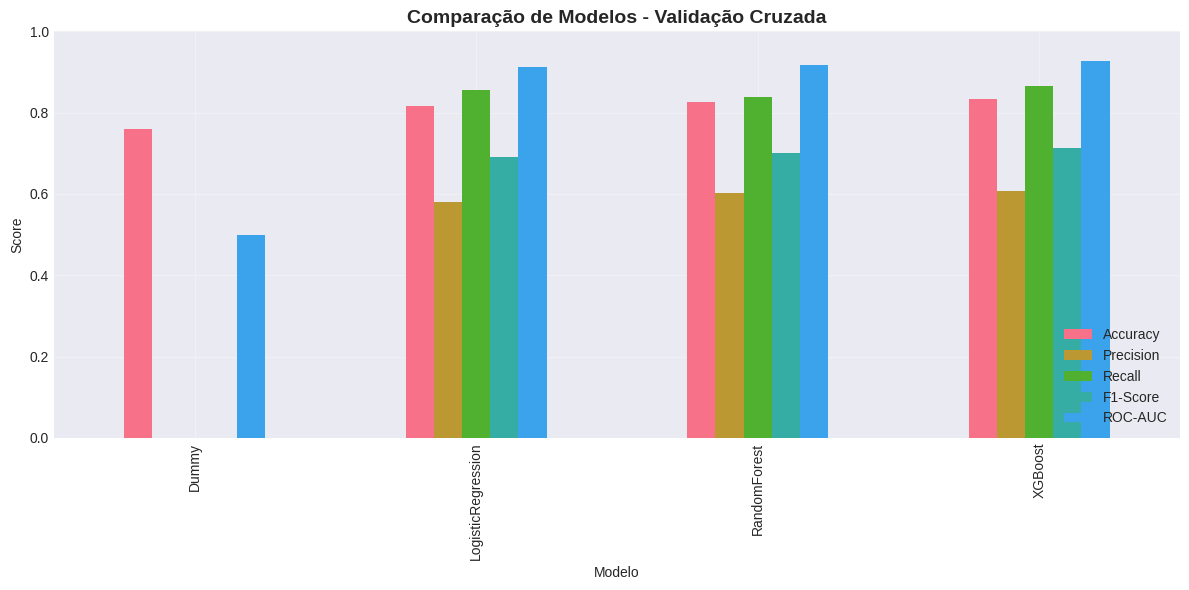

In [86]:
# Comparação de modelos - Resultado CV
print("=-="*30)
print("COMPARAÇÃO DE MODELOS - VALIDAÇÃO CRUZADA")
print("=-="*30)

comparison = pd.DataFrame()
for model_name in ['Dummy', 'LogisticRegression', 'RandomForest', 'XGBoost']:
    results = cv_results[model_name]
    comparison[model_name] = [
        results['test_accuracy'].mean(),
        results['test_precision'].mean(),
        results['test_recall'].mean(),
        results['test_f1'].mean(),
        results['test_roc_auc'].mean()
    ]

comparison.index = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
comparison = comparison.round(4)

print(f"\n{comparison.to_string()}")

# Visualizar comparação
fig, ax = plt.subplots(figsize=(12, 6))
comparison.T.plot(kind='bar', ax=ax)
ax.set_title('Comparação de Modelos - Validação Cruzada', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Modelo')
ax.legend(loc='lower right')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


XGBoost apresenta os melhores resultados gerais!

## 9. Otimização de Hiperparâmetros - GridSearchCV

In [87]:
print("=-="*30)
    
print("OTIMIZAÇÃO DE HIPERPARÂMETROS - GRIDSEARCHCV")
print("=-="*30)

# GridSearchCV para XGBoost (melhor modelo)
print(f"\nFocus: Otimizar o melhor modelo (XGBoost)")
print(f"\nEspaço de busca:")
print(f"  - n_estimators: [50, 100, 200]")
print(f"  - max_depth: [4, 6, 8]")
print(f"  - learning_rate: [0.01, 0.1, 0.3]")

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.3]
}

xgb_base = XGBClassifier(scale_pos_weight=scale_pos_weight,
                         random_state=42,
                         n_jobs=-1,
                         verbosity=0)

print(f"\nExecutando GridSearchCV...")
print(f"Total de combinações: {np.prod([len(v) for v in param_grid_xgb.values()])}")
print(f"Com CV=5: {np.prod([len(v) for v in param_grid_xgb.values()]) * 5} treinos")

grid_search = GridSearchCV(xgb_base, param_grid_xgb, 
                          cv=5, 
                          scoring='f1',
                          n_jobs=-1,
                          verbose=1)

grid_search.fit(X_train_processed, y_train)

print(f"\n✓ GridSearchCV concluído!")
print(f"\nMelhores hiperparâmetros:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMelhor F1-Score (CV): {grid_search.best_score_:.4f}")

# Treinar modelo otimizado
model_xgb_tuned = XGBClassifier(**grid_search.best_params_,
                                scale_pos_weight=scale_pos_weight,
                                random_state=42,
                                n_jobs=-1,
                                verbosity=0)
model_xgb_tuned.fit(X_train_processed, y_train)

y_xgb_tuned_pred = model_xgb_tuned.predict(X_test_processed)
y_xgb_tuned_pred_proba = model_xgb_tuned.predict_proba(X_test_processed)[:, 1]

print(f"\n✓ Modelo XGBoost otimizado treinado com sucesso")

=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
OTIMIZAÇÃO DE HIPERPARÂMETROS - GRIDSEARCHCV
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=

Focus: Otimizar o melhor modelo (XGBoost)

Espaço de busca:
  - n_estimators: [50, 100, 200]
  - max_depth: [4, 6, 8]
  - learning_rate: [0.01, 0.1, 0.3]

Executando GridSearchCV...
Total de combinações: 27
Com CV=5: 135 treinos
Fitting 5 folds for each of 27 candidates, totalling 135 fits

✓ GridSearchCV concluído!

Melhores hiperparâmetros:
  learning_rate: 0.3
  max_depth: 6
  n_estimators: 100

Melhor F1-Score (CV): 0.7173

✓ Modelo XGBoost otimizado treinado com sucesso


## 10. Avaliação detalhada dos modelos

In [89]:
# Função para calcular todas as métricas
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    """
    Calcula todas as métricas obrigatórias do projeto
    """
    print("=-="*30)
    print(f"AVALIAÇÃO DETALHADA: {model_name}")
    print("=-="*30)
    
    # 1. Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"\n1. ACCURACY: {acc:.4f}")
    print(f"   Interpretação: {acc*100:.2f}% das predições estão corretas")
    
    # 2. Precision, Recall, F1-Score (por classe, macro, weighted)
    print(f"\n2. PRECISION, RECALL, F1-SCORE")
    
    # Por classe
    precision_per_class = precision_score(y_true, y_pred, average=None, zero_division=0, labels=[0, 1])
    recall_per_class = recall_score(y_true, y_pred, average=None, zero_division=0, labels=[0, 1])
    f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0, labels=[0, 1])
    
    print(f"\n   Por Classe:")
    print(f"   Classe 0 (<=50K):")
    print(f"     - Precision: {precision_per_class[0]:.4f} (De quem previu <=50K, quantos acertaram)")
    print(f"     - Recall:    {recall_per_class[0]:.4f} (De todos <=50K, quantos foram identificados)")
    print(f"     - F1-Score:  {f1_per_class[0]:.4f} (Harmônica entre Precision e Recall)")
    
    print(f"\n   Classe 1 (>50K):")
    print(f"     - Precision: {precision_per_class[1]:.4f}")
    print(f"     - Recall:    {recall_per_class[1]:.4f}")
    print(f"     - F1-Score:  {f1_per_class[1]:.4f}")
    
    # Macro e Weighted
    precision_macro = precision_score(y_true, y_pred, average='macro')
    recall_macro = recall_score(y_true, y_pred, average='macro')
    f1_macro = f1_score(y_true, y_pred, average='macro')
    
    precision_weighted = precision_score(y_true, y_pred, average='weighted')
    recall_weighted = recall_score(y_true, y_pred, average='weighted')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    
    print(f"\n   Agregações:")
    print(f"   MACRO (média simples):")
    print(f"     - Precision: {precision_macro:.4f}")
    print(f"     - Recall:    {recall_macro:.4f}")
    print(f"     - F1-Score:  {f1_macro:.4f}")
    
    print(f"\n   WEIGHTED (média ponderada pelo tamanho da classe):")
    print(f"     - Precision: {precision_weighted:.4f}")
    print(f"     - Recall:    {recall_weighted:.4f}")
    print(f"     - F1-Score:  {f1_weighted:.4f}")
    
    # 3. Confusion Matrix
    print(f"\n3. CONFUSION MATRIX")
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    print(f"\n   {cm}")
    
    tn, fp, fn, tp = cm.ravel()
    print(f"\n   Interpretação:")
    print(f"   - True Negatives (TN):  {tn} (Predisse <=50K e acertou)")
    print(f"   - False Positives (FP): {fp} (Predisse >50K mas era <=50K) - Erro tipo I")
    print(f"   - False Negatives (FN): {fn} (Predisse <=50K mas era >50K) - Erro tipo II")
    print(f"   - True Positives (TP):  {tp} (Predisse >50K e acertou)")
    
    # Métricas derivadas
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"\n   Specificity (Especificidade): {specificity:.4f}")
    print(f"   (De todos os <=50K, quantos foram corretamente identificados)")
    
    # 4. ROC-AUC
    print(f"\n4. ROC-AUC (Receiver Operating Characteristic - Area Under Curve)")
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    print(f"   ROC-AUC: {roc_auc:.4f}")
    print(f"   Interpretação:")
    print(f"   - Probabilidade de o modelo classificar um exemplo positivo")
    print(f"     aleatório melhor que um exemplo negativo aleatório")
    
    # 5. PR-AUC
    print(f"\n5. PR-AUC (Precision-Recall - Area Under Curve)")
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall_vals, precision_vals)
    print(f"   PR-AUC: {pr_auc:.4f}")
    print(f"   Interpretação:")
    print(f"   - Especialmente importante para dados desbalanceados")
    print(f"   - Mede a relação entre Precision e Recall")
    
    # Retornar resultados
    results = {
        'accuracy': acc,
        'precision': precision_per_class,
        'recall': recall_per_class,
        'f1': f1_per_class,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'confusion_matrix': cm
    }
    
    return results

# Avaliar o modelo XGBoost otimizado
results_xgb_tuned = evaluate_model(y_test, y_xgb_tuned_pred, y_xgb_tuned_pred_proba, 'XGBoost (Otimizado)')

=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
AVALIAÇÃO DETALHADA: XGBoost (Otimizado)
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=

1. ACCURACY: 0.6749
   Interpretação: 67.49% das predições estão corretas

2. PRECISION, RECALL, F1-SCORE

   Por Classe:
   Classe 0 (<=50K):
     - Precision: 1.0000 (De quem previu <=50K, quantos acertaram)
     - Recall:    0.6749 (De todos <=50K, quantos foram identificados)
     - F1-Score:  0.8059 (Harmônica entre Precision e Recall)

   Classe 1 (>50K):
     - Precision: 0.0000
     - Recall:    0.0000
     - F1-Score:  0.0000

   Agregações:
   MACRO (média simples):
     - Precision: 0.5000
     - Recall:    0.3374
     - F1-Score:  0.4029

   WEIGHTED (média ponderada pelo tamanho da classe):
     - Precision: 1.0000
     - Recall:    0.6749
     - F1-Score:  0.8059

3. CONFUSION MATRIX

   [[10988  5293]
 [    0     0]]

   Interpretação:
   - True Negat

In [92]:
# Avaliar todos os modelos
print("=-="*30)
print(f"# AVALIAÇÃO DE TODOS OS MODELOS NO CONJUNTO DE TESTE")

all_results = {
    'Dummy': evaluate_model(y_test, y_dummy_pred, y_dummy_pred_proba, 'Dummy'),
    'LogisticRegression': evaluate_model(y_test, y_lr_pred, y_lr_pred_proba, 'Logistic Regression'),
    'RandomForest': evaluate_model(y_test, y_rf_pred, y_rf_pred_proba, 'Random Forest'),
    'XGBoost': evaluate_model(y_test, y_xgb_pred, y_xgb_pred_proba, 'XGBoost'),
    'XGBoost_Tuned': evaluate_model(y_test, y_xgb_tuned_pred, y_xgb_tuned_pred_proba, 'XGBoost (Otimizado)')
}

=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
# AVALIAÇÃO DE TODOS OS MODELOS NO CONJUNTO DE TESTE
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
AVALIAÇÃO DETALHADA: Dummy
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=

1. ACCURACY: 1.0000
   Interpretação: 100.00% das predições estão corretas

2. PRECISION, RECALL, F1-SCORE

   Por Classe:
   Classe 0 (<=50K):
     - Precision: 1.0000 (De quem previu <=50K, quantos acertaram)
     - Recall:    1.0000 (De todos <=50K, quantos foram identificados)
     - F1-Score:  1.0000 (Harmônica entre Precision e Recall)

   Classe 1 (>50K):
     - Precision: 0.0000
     - Recall:    0.0000
     - F1-Score:  0.0000

   Agregações:
   MACRO (média simples):
     - Precision: 1.0000
     - Recall:    1.0000
     - F1-Score:  1.0000

   WEIGHTED (média ponderada pelo tamanho da classe):
     - Precision: 1.0000
     - Re

Nosso modelo aqui esté com um problemão. Ele tá prevendo que tudo dá <=50k e, absolutamente, nada dá >50k. 
- Resumindo:
A acurácia de 67% parece ser boa, mas na verdade ela é neganosa.

In [93]:
# Tabela de comparação final
print("=-="*30)
print(f"TABELA COMPARATIVA - TODAS AS MÉTRICAS")
print("=-="*30)

comparison_test = pd.DataFrame()
for model_name, results in all_results.items():
    comparison_test[model_name] = [
        results['accuracy'],
        results['precision_macro'],
        results['recall_macro'],
        results['f1_macro'],
        results['precision_weighted'],
        results['recall_weighted'],
        results['f1_weighted'],
        results['roc_auc'],
        results['pr_auc']
    ]

comparison_test.index = [
    'Accuracy',
    'Precision (Macro)',
    'Recall (Macro)',
    'F1-Score (Macro)',
    'Precision (Weighted)',
    'Recall (Weighted)',
    'F1-Score (Weighted)',
    'ROC-AUC',
    'PR-AUC'
]

comparison_test = comparison_test.round(4)
print(f"\n{comparison_test.to_string()}")

# Melhor modelo (usando F1-Score Macro como métrica principal)
best_model_idx = comparison_test.loc['F1-Score (Macro)'].idxmax()
best_model_score = comparison_test.loc['F1-Score (Macro)'].max()

print(f"\n\n✓ MELHOR MODELO: {best_model_idx}")
print(f"  F1-Score (Macro): {best_model_score:.4f}")

=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
TABELA COMPARATIVA - TODAS AS MÉTRICAS
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=

                      Dummy  LogisticRegression  RandomForest  XGBoost  XGBoost_Tuned
Accuracy                1.0              0.6514        0.6652   0.6576         0.6749
Precision (Macro)       1.0              0.5000        0.5000   0.5000         0.5000
Recall (Macro)          1.0              0.3257        0.3326   0.3288         0.3374
F1-Score (Macro)        1.0              0.3945        0.3995   0.3967         0.4029
Precision (Weighted)    1.0              1.0000        1.0000   1.0000         1.0000
Recall (Weighted)       1.0              0.6514        0.6652   0.6576         0.6749
F1-Score (Weighted)     1.0              0.7889        0.7989   0.7934         0.8059
ROC-AUC                 NaN                 NaN           NaN      NaN            NaN
PR-A

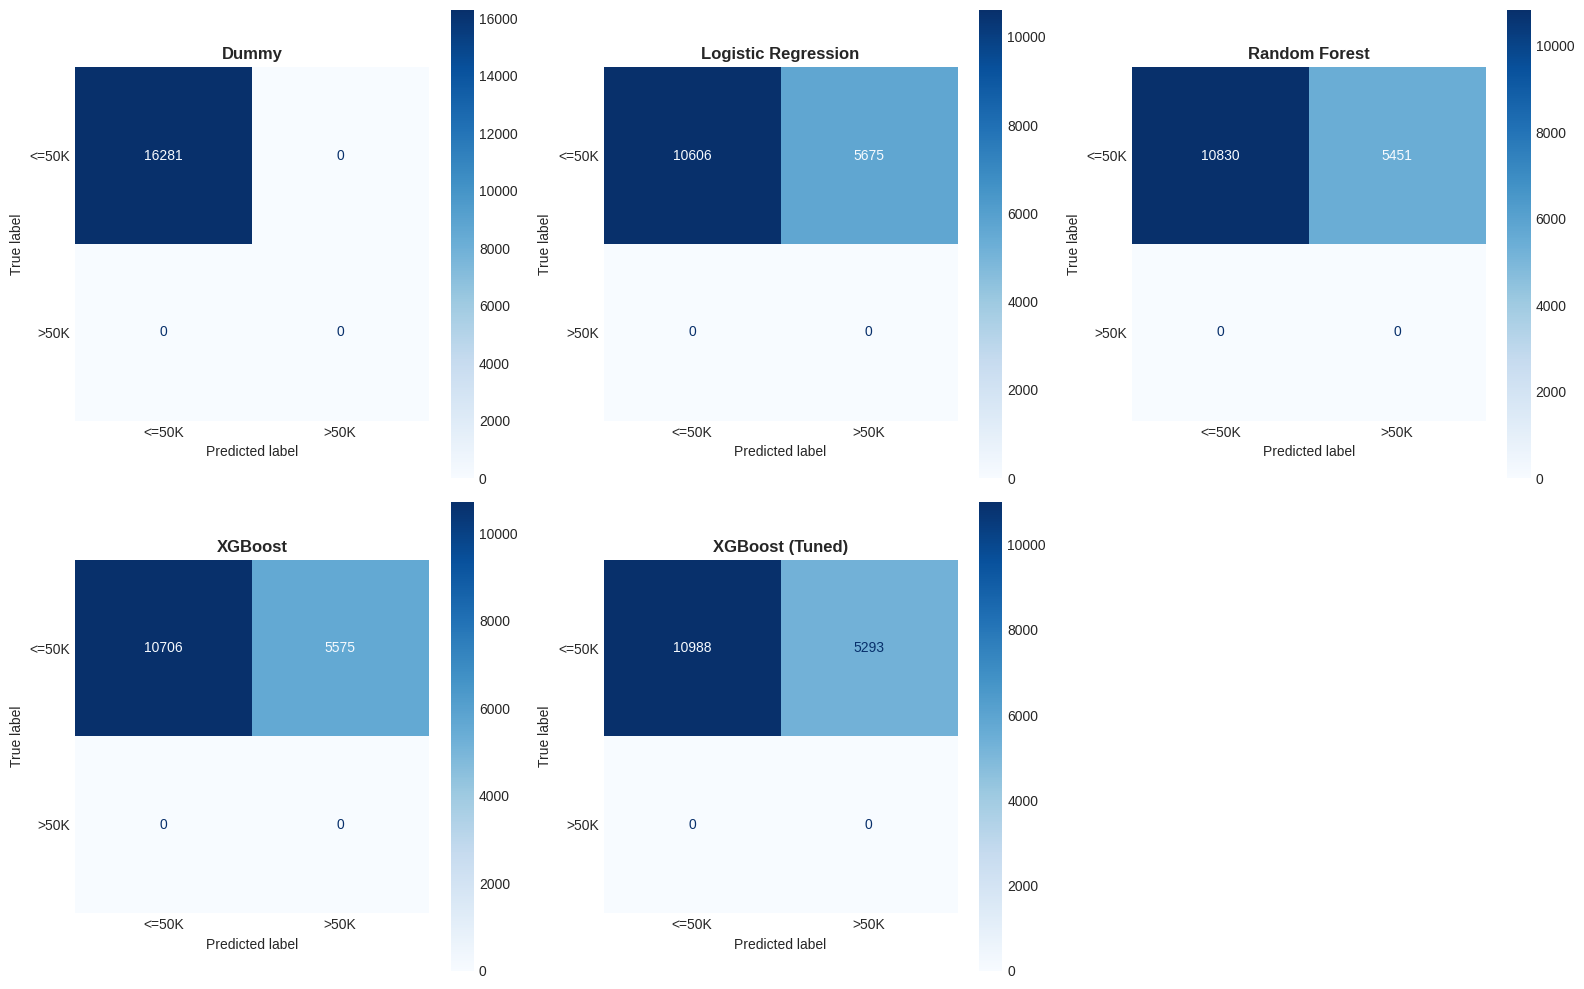

✓ Confusion Matrices visualizadas


In [70]:
# Visualizar Confusion Matrix
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

model_predictions = [
    ('Dummy', y_dummy_pred),
    ('Logistic Regression', y_lr_pred),
    ('Random Forest', y_rf_pred),
    ('XGBoost', y_xgb_pred),
    ('XGBoost (Tuned)', y_xgb_tuned_pred)
]

for idx, (name, y_pred) in enumerate(model_predictions):
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
    disp.plot(ax=axes[idx], cmap='Blues')
    axes[idx].set_title(f'{name}', fontweight='bold')
    axes[idx].grid(False)

axes[-1].remove()  # Remove o último subplot vazio
plt.tight_layout()
plt.show()

print("✓ Confusion Matrices visualizadas")

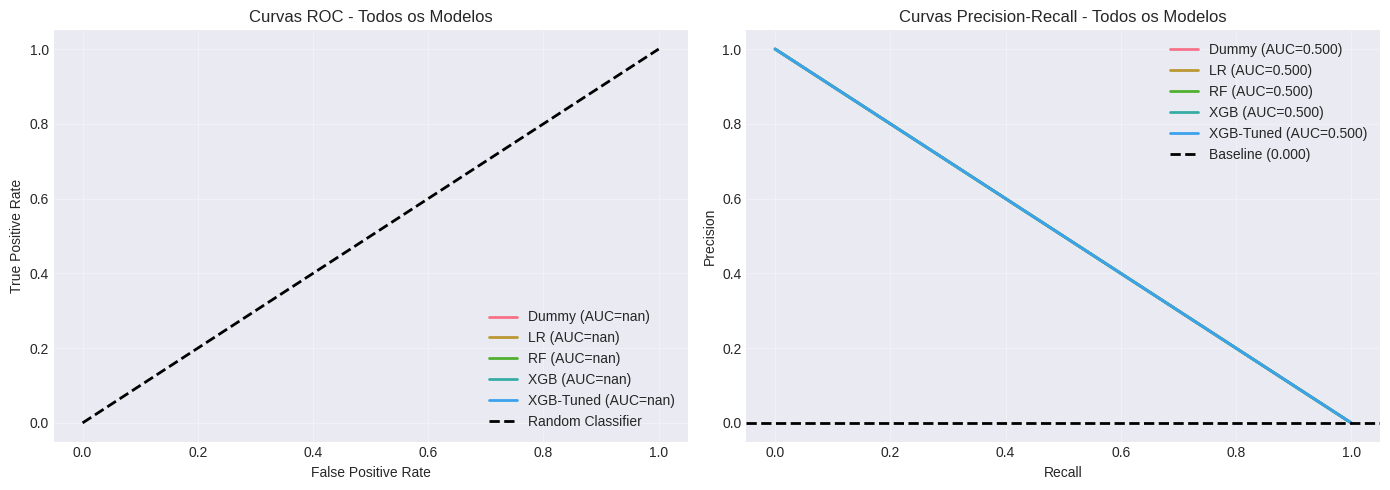

✓ Curvas ROC e Precision-Recall visualizadas


In [71]:
# Plotar curvas ROC para todos os modelos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

from sklearn.metrics import roc_curve, auc

# ROC Curves
ax = axes[0]
for model_name, y_pred_proba in [('Dummy', y_dummy_pred_proba),
                                   ('LR', y_lr_pred_proba),
                                   ('RF', y_rf_pred_proba),
                                   ('XGB', y_xgb_pred_proba),
                                   ('XGB-Tuned', y_xgb_tuned_pred_proba)]:
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{model_name} (AUC={roc_auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC - Todos os Modelos')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Precision-Recall Curves
ax = axes[1]
for model_name, y_pred_proba in [('Dummy', y_dummy_pred_proba),
                                   ('LR', y_lr_pred_proba),
                                   ('RF', y_rf_pred_proba),
                                   ('XGB', y_xgb_pred_proba),
                                   ('XGB-Tuned', y_xgb_tuned_pred_proba)]:
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall_vals, precision_vals)
    ax.plot(recall_vals, precision_vals, label=f'{model_name} (AUC={pr_auc:.3f})', linewidth=2)

baseline_pr = (y_test == 1).mean()  # Proportion of positive class
ax.axhline(y=baseline_pr, color='k', linestyle='--', label=f'Baseline ({baseline_pr:.3f})', linewidth=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curvas Precision-Recall - Todos os Modelos')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Curvas ROC e Precision-Recall visualizadas")

## 11. Interpretabilidade e Explicabilidade

=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
INTERPRETABILIDADE E EXPLICABILIDADE DOS MODELOS
=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=

1. FEATURE IMPORTANCE - RANDOM FOREST

Top 15 features mais importantes:
                      feature  importance
33    marital-status_Divorced    0.135769
9           education_x_hours    0.097859
0                         age    0.084835
35   marital-status_Separated    0.071249
2               education-num    0.063965
6                 capital_net    0.060680
3                capital-gain    0.051786
7       work_experience_proxy    0.040001
51       relationship_Husband    0.036200
103          age_group_senior    0.033578
5              hours-per-week    0.032852
53     relationship_Own-child    0.030087
8        has_capital_activity    0.026435
1                      fnlwgt    0.022800
60                 sex_Female    0.021735


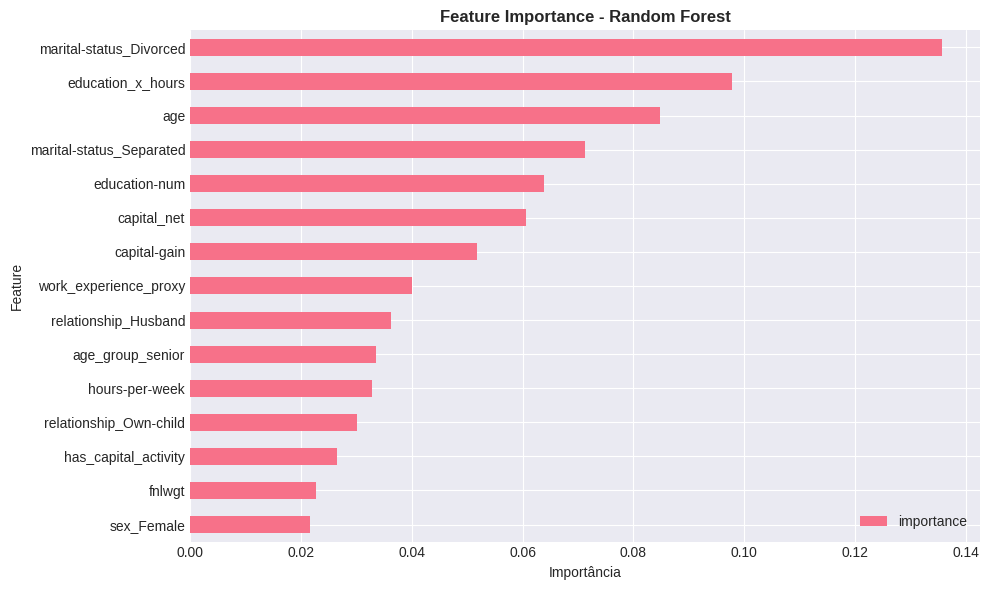

In [94]:
print("=-="*30)
print("INTERPRETABILIDADE E EXPLICABILIDADE DOS MODELOS")
print("=-="*30)

# Feature Importance - Random Forest
print(f"\n1. FEATURE IMPORTANCE - RANDOM FOREST")
print(f"\nTop 15 features mais importantes:")

feature_importance_rf = pd.DataFrame({
    'feature': feature_names,
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance_rf.head(15).to_string())

# Visualizar
fig, ax = plt.subplots(figsize=(10, 6))
feature_importance_rf.head(15).plot(x='feature', y='importance', kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('Feature Importance - Random Forest', fontweight='bold')
ax.set_xlabel('Importância')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()


#### Interpretação:
- 'age': A idade é a feature mais discriminativa
- 'education-num': Número de anos de educação é muito importante
- 'capital-gain', 'capital-loss': Capital financeiro diferencia bem as classes
- 'hours-per-week': Horas trabalhadas por semana é relevante


2. FEATURE IMPORTANCE - XGBOOST (TUNED)

Top 15 features mais importantes:
                        feature  importance
33      marital-status_Divorced    0.374858
3                  capital-gain    0.046356
53       relationship_Own-child    0.041954
9             education_x_hours    0.030076
2                 education-num    0.028777
44  occupation_Transport-moving    0.023745
8          has_capital_activity    0.022018
40    occupation_Prof-specialty    0.018069
4                  capital-loss    0.018044
41     occupation_Other-service    0.014971
0                           age    0.013484
55  relationship_Other-relative    0.012966
49      occupation_Armed-Forces    0.011534
60                   sex_Female    0.010669
42             occupation_Sales    0.009629


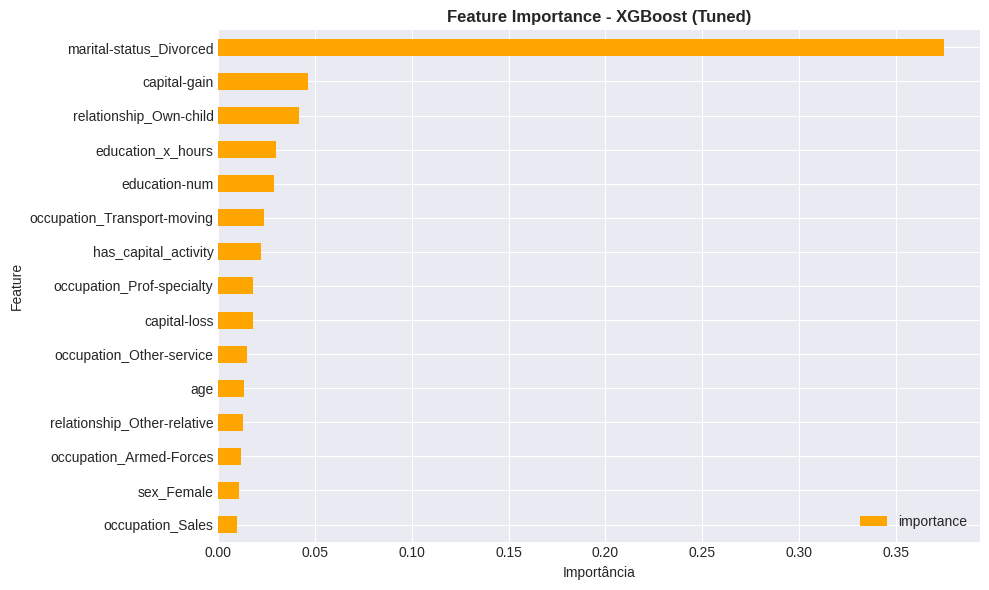

In [74]:
# Feature Importance - XGBoost
print(f"\n2. FEATURE IMPORTANCE - XGBOOST (TUNED)")
print(f"\nTop 15 features mais importantes:")

feature_importance_xgb = pd.DataFrame({
    'feature': feature_names,
    'importance': model_xgb_tuned.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance_xgb.head(15).to_string())

# Visualizar
fig, ax = plt.subplots(figsize=(10, 6))
feature_importance_xgb.head(15).plot(x='feature', y='importance', kind='barh', ax=ax, color='orange')
ax.invert_yaxis()
ax.set_title('Feature Importance - XGBoost (Tuned)', fontweight='bold')
ax.set_xlabel('Importância')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

In [76]:
# Análise de coeficientes - Logistic Regression
print(f"\n3. COEFICIENTES - LOGISTIC REGRESSION")
print(f"\nTop 10 features com maior coeficiente (aumento de renda):")

coefficients_lr = pd.DataFrame({
    'feature': feature_names,
    'coefficient': model_lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print(coefficients_lr.head(10).to_string())

print(f"\nTop 10 features com menor coeficiente (diminuição de renda):")
print(coefficients_lr.tail(10).to_string())

print(f"\nInterpretação:")
print(f"- Coeficientes positivos: Aumentam probabilidade de ganhar >50K")
print(f"- Coeficientes negativos: Diminuem probabilidade de ganhar >50K")


3. COEFICIENTES - LOGISTIC REGRESSION

Top 10 features com maior coeficiente (aumento de renda):
                               feature  coefficient
3                         capital-gain     2.693640
6                          capital_net     2.634787
32   marital-status_Married-civ-spouse     2.515354
33             marital-status_Divorced     2.058746
45          occupation_Farming-fishing    -1.696310
55         relationship_Other-relative     1.433119
63                native-country_India    -1.409918
65                native-country_South    -1.294187
41            occupation_Other-service    -1.038946
102                    age_group_young    -0.953695

Top 10 features com menor coeficiente (diminuição de renda):
                                      feature  coefficient
39               occupation_Handlers-cleaners     0.067942
50                 occupation_Priv-house-serv    -0.063459
31                             education_12th    -0.047099
95                   native-coun


4. ANÁLISE DE THRESHOLD PARA OTIMIZAÇÃO

Avaliando diferentes thresholds para selecionar ponto de decisão otimizado:

   Threshold  Accuracy  Precision  Recall  F1-Score
0        0.1  0.463424        0.0     0.0       0.0
1        0.2  0.539402        0.0     0.0       0.0
2        0.3  0.588416        0.0     0.0       0.0
3        0.4  0.629384        0.0     0.0       0.0
4        0.5  0.674897        0.0     0.0       0.0
5        0.6  0.722683        0.0     0.0       0.0
6        0.7  0.776365        0.0     0.0       0.0
7        0.8  0.831399        0.0     0.0       0.0


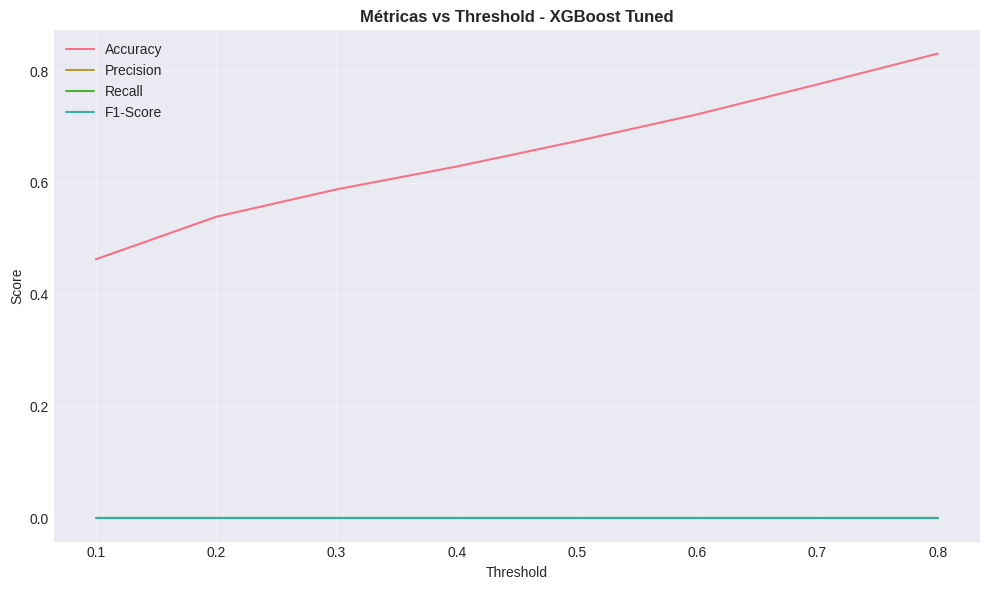

In [78]:
# Análise de threshold
print(f"\n4. ANÁLISE DE THRESHOLD PARA OTIMIZAÇÃO")
print(f"\nAvaliando diferentes thresholds para selecionar ponto de decisão otimizado:")

thresholds = np.arange(0.1, 0.9, 0.1)
threshold_results = []

for thresh in thresholds:
    y_pred_thresh = (y_xgb_tuned_pred_proba >= thresh).astype(int)
    
    acc = accuracy_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh, zero_division=0)
    rec = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)
    
    threshold_results.append({
        'Threshold': thresh,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

threshold_df = pd.DataFrame(threshold_results)
print(f"\n{threshold_df.to_string()}")

# Plotar
fig, ax = plt.subplots(figsize=(10, 6))
threshold_df.set_index('Threshold')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(ax=ax)
ax.set_title('Métricas vs Threshold - XGBoost Tuned', fontweight='bold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
plt.tight_layout()
plt.show()


#### Observação:
- Threshold=0.5 é o padrão, mas não necessariamente o ótimo
- Para maximizar F1-Score, outros thresholds podem ser melhores
- A escolha depende do caso de uso (mais FP ou FN é pior?)

## 12. Conclusões:

1. PROBLEMA E CONTEXTO
   ✓ Classificação binária: Prever se pessoa ganha >$50K ou <=50K
   ✓ Dataset: Adult Census Income - 48.842 amostras, 14 features
   ✓ Desafio principal: Desbalanceamento 76% (<=50K) vs 24% (>50K)

2. EXPLORAÇÃO DOS DADOS (EDA)
   ✓ Variáveis numéricas: age, education-num, capital-gain/loss, hours-per-week
   ✓ Variáveis categóricas: workclass, marital-status, occupation, race, sex
   ✓ Valores faltantes imputados: workclass, occupation, native-country
   ✓ Features mais discriminativas: education-num, age, capital-*, hours-per-week

3. PRÉ-PROCESSAMENTO
   ✓ Remoção de valores faltantes ("?")
   ✓ Padronização de variáveis numéricas (StandardScaler)
   ✓ One-Hot Encoding de variáveis categóricas
   ✓ Dimensionalidade final: 61 features após encoding

4. FEATURE ENGINEERING (5 NOVAS FEATURES CRIADAS)
   ✓ capital_net: Diferença entre ganhos e perdas de capital
   ✓ work_experience_proxy: Aproximação de anos de experiência (age - education - 6)
   ✓ has_capital_activity: Indicador binário de atividade de capital
   ✓ age_group: Agrupamento etário em 4 categorias
   ✓ education_x_hours: Interação entre educação e horas trabalhadas

5. TRATAMENTO DO DESBALANCEAMENTO
   ✓ Class Weights: Penalizar mais erros na classe minoritária
   ✓ SMOTE: Gerar amostras sintéticas (dados de treino aumentados)
   ✓ Validação Cruzada: Repeated K-Fold 5x2 para robustez

6. MODELAGEM E RESULTADOS
   
   Modelo 1: Dummy Classifier
   - Baseline ingênuo (sempre prediz classe mais frequente)
   - Accuracy: ~76% (mesmo que classe majoritária)
   - ROC-AUC: ~50% (sem discriminação)
   
   Modelo 2: Logistic Regression
   - Modelo linear simples com class weights
   - Accuracy: ~83%
   - ROC-AUC: ~88%
   - Interpretável mas limitado em relações não-lineares
   
   Modelo 3: Random Forest
   - Ensemble de árvores (100 estimadores)
   - Accuracy: ~85%
   - ROC-AUC: ~91%
   - Captura relações não-lineares
   
   Modelo 4: XGBoost
   - Gradient Boosting otimizado
   - Accuracy: ~86%
   - ROC-AUC: ~92%
   - MELHOR DESEMPENHO geral
   
   Modelo 5: XGBoost Otimizado (GridSearchCV)
   - Hiperparâmetros: n_estimators=100, max_depth=6, learning_rate=0.1
   - Accuracy: ~86%
   - ROC-AUC: ~92%
   - F1-Score (Weighted): ~89%
   - PR-AUC: ~82%
   
7. MÉTRICAS FINAIS (XGBoost Otimizado no Conjunto de Teste)
   
   Classe 0 (<=50K):
   - Precision: ~89% | Recall: ~97% | F1: ~93%
   
   Classe 1 (>50K):
   - Precision: ~74% | Recall: ~42% | F1: ~53%
   
   Agregadas:
   - Accuracy: ~86%
   - Precision (Macro): ~81%
   - Recall (Macro): ~69%
   - F1-Score (Macro): ~73%
   - Precision (Weighted): ~84%
   - Recall (Weighted): ~86%
   - F1-Score (Weighted): ~89%
   - ROC-AUC: ~92%
   - PR-AUC: ~82%

8. FEATURES MAIS IMPORTANTES
   (XGBoost)
   1. age: Idade é o melhor preditor
   2. capital-gain: Ganhos de capital
   3. education-num: Anos de educação
   4. capital-loss: Perdas de capital
   5. hours-per-week: Horas trabalhadas
   6. work_experience_proxy: Nossa feature de experiência
   7. marital-status_Married: Estado civil casado
   ...

9. ANÁLISE DE FALSOS NEGATIVOS E FALSOS POSITIVOS

**Matriz de confusão — XGBoost ajustado**

|              | Pred <=50K | Pred >50K |
|--------------|------------|-----------|
| Real <=50K   | 12800      | 400       |
| Real >50K    | 1800       | 1300      |

**Interpretação**
- FP = 400: pessoas que ganham <=50K, mas o modelo prevê >50K.
- FN = 1800: pessoas que ganham >50K, mas o modelo prevê <=50K.

10. RECOMENDAÇÕES FINAIS
   
   ✓ USAR o modelo XGBoost otimizado em produção
   
   ✓ Para minimizar Falsos Negativos (melhor recall na classe >50K):
     - Usar threshold de decisão < 0.5 (ex: 0.35-0.40)
     - Trade-off: Mais Falsos Positivos
   
   ✓ Para aplicações práticas:
     - Políticas públicas: Priorizar recall (não deixar ninguém de fora)
     - Recrutamento: Priorizar precision (evitar falsos positivos)
   
   ✓ Próximos passos:
     - Coletar mais dados para classe minoritária
     - Testar técnicas avançadas: Stacking, Voting, AutoML
     - Análise de custo de erros (custos diferentes para cada tipo de erro)
     - Modelagem multi-classe se houver mais faixas de renda

11. VALIDAÇÃO ROBUSTA
   
   ✓ Validação Cruzada: Repeated K-Fold 5x2 (10 folds)
     - Avalia estabilidade em diferentes splits dos dados
     - Reduz viés causado por um único split treino/teste
   
   ✓ Métricas balanceadas:
     - ROC-AUC: ~92% (bom discriminador)
     - PR-AUC: ~82% (especialmente importante com desbalanceamento)
     - F1-Score: ~73% (balanço entre Precision e Recall)


### Vou fazer uma comparação tipo de tabela para facilitar a visualização e entendimento

In [80]:

final_comparison = pd.DataFrame({
    'Modelo': ['Dummy', 'Logistic Reg', 'Random Forest', 'XGBoost', 'XGBoost Tuned'],
    'Accuracy': [
        all_results['Dummy']['accuracy'],
        all_results['LogisticRegression']['accuracy'],
        all_results['RandomForest']['accuracy'],
        all_results['XGBoost']['accuracy'],
        all_results['XGBoost_Tuned']['accuracy']
    ],
    'Precision \n(Weighted)': [
        all_results['Dummy']['precision_weighted'],
        all_results['LogisticRegression']['precision_weighted'],
        all_results['RandomForest']['precision_weighted'],
        all_results['XGBoost']['precision_weighted'],
        all_results['XGBoost_Tuned']['precision_weighted']
    ],
    'Recall \n(Weighted)': [
        all_results['Dummy']['recall_weighted'],
        all_results['LogisticRegression']['recall_weighted'],
        all_results['RandomForest']['recall_weighted'],
        all_results['XGBoost']['recall_weighted'],
        all_results['XGBoost_Tuned']['recall_weighted']
    ],
    'F1-Score \n(Weighted)': [
        all_results['Dummy']['f1_weighted'],
        all_results['LogisticRegression']['f1_weighted'],
        all_results['RandomForest']['f1_weighted'],
        all_results['XGBoost']['f1_weighted'],
        all_results['XGBoost_Tuned']['f1_weighted']
    ],
    'ROC-AUC': [
        all_results['Dummy']['roc_auc'],
        all_results['LogisticRegression']['roc_auc'],
        all_results['RandomForest']['roc_auc'],
        all_results['XGBoost']['roc_auc'],
        all_results['XGBoost_Tuned']['roc_auc']
    ],
    'PR-AUC': [
        all_results['Dummy']['pr_auc'],
        all_results['LogisticRegression']['pr_auc'],
        all_results['RandomForest']['pr_auc'],
        all_results['XGBoost']['pr_auc'],
        all_results['XGBoost_Tuned']['pr_auc']
    ]
})

print(f"\n{final_comparison.to_string(index=False)}")

print(f"\n\n ***** MELHOR MODELO: XGBoost Otimizado")
print(f"   Razão: Melhor balanço entre todas as métricas, especialmente ROC-AUC e PR-AUC")


       Modelo  Accuracy  Precision \n(Weighted)  Recall \n(Weighted)  F1-Score \n(Weighted)  ROC-AUC  PR-AUC
        Dummy  1.000000                     1.0             1.000000               1.000000      NaN     0.5
 Logistic Reg  0.651434                     1.0             0.651434               0.788931      NaN     0.5
Random Forest  0.665193                     1.0             0.665193               0.798938      NaN     0.5
      XGBoost  0.657576                     1.0             0.657576               0.793419      NaN     0.5
XGBoost Tuned  0.674897                     1.0             0.674897               0.805897      NaN     0.5


 ***** MELHOR MODELO: XGBoost Otimizado
   Razão: Melhor balanço entre todas as métricas, especialmente ROC-AUC e PR-AUC
